In [1]:
# Install library jika belum tersedia
!pip install scikit-learn pandas numpy seaborn matplotlib imbalanced-learn requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

from imblearn.pipeline import Pipeline # Disarankan jika ada penanganan imbalanced data
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel


In [2]:
# Download Dataset IoT Vulnerability Dataset
url = "https://data.mendeley.com/public-files/datasets/7m58kxs742/files/4d57de6a-a140-4607-bf38-146899f1a723/file_downloaded"
file_name = "Preprocessed_Balanced_dataset.csv"

print(f"Downloading {file_name}...")
response = requests.get(url)

if response.status_code == 200:
    with open(file_name, "wb") as f:
        f.write(response.content)
    print(f"{file_name} berhasil diunduh.\n")
else:
    print(f"Gagal mengunduh {file_name}. Status code: {response.status_code}\n")

# Load Dataset
df = pd.read_csv(file_name)
display(df.head())


Preprocessed_Balanced_dataset.csv berhasil diunduh.



,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category,Attack_sub_category
0,0.143546,1,42,1,1,4,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
1,0.000679,1,42,1,1,3,4,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
2,0.010981,1,42,1,1,11,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
3,0.000684,1,42,1,1,3,24,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
4,0.012461,1,42,1,1,12,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning


### 3.1. Informasi & Statistik Dataset
Langkah pertama dalam EDA adalah memahami struktur data dasar, melihat tipe data setiap fitur, distribusi statistik dasar (mean, standar deviasi, min, max), serta memastikan tidak ada *missing values* (data kosong). Karena dataset ini berstatus *Preprocessed*, diharapkan data sudah bersih dari nilai *null*.


In [3]:
# Melihat informasi umum dataset (tipe data dan jumlah baris/kolom)
print("=== INFORMASI DATASET ===")
df.info()

# Melihat statistik deskriptif dataset
print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe())

# Mengecek apakah ada missing values (data kosong)
print("\n=== JUMLAH MISSING VALUES ===")
print(df.isnull().sum().sum(), "Missing Values ditemukan secara total.")

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 88 columns):
 #   Column                                                      Non-Null Count    Dtype  
---  ------                                                      --------------    -----  
 0   dur                                                         1048575 non-null  float64
 1   Protocol                                                    1048575 non-null  int64  
 2   Length                                                      1048575 non-null  int64  
 3   Source Host                                                 1048575 non-null  int64  
 4   Destination Host                                            1048575 non-null  int64  
 5   Sender IP address                                           1048575 non-null  int64  
 6   Target IP address                                           1048575 non-null  int64  
 7   Opcode                               

,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Length.1,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,4.171936e-02,2.142777e+01,1.122461e+02,5.407739e+04,3.146737e+03,1.291301e+00,1.740716e+00,9.528074e-01,7.505833e+03,3.418249e+03,...,7.273493e+00,3.091251e+00,2.824882e+05,8.664197e-01,2.366918e+00,8.781356e-01,3.735265e+03,8.441075e-01,9.154567e-01,2.449181e+00
std,1.914513e-01,1.107721e+01,2.385786e+02,3.109492e+04,1.511347e+03,1.921420e+00,4.199544e+00,5.890998e-01,1.464353e+04,9.841633e+03,...,8.293642e+01,1.985971e+00,4.058329e+06,3.541635e-01,3.897197e+00,3.910057e-01,1.050825e+04,3.760974e-01,2.782010e-01,2.230851e+00
min,-1.606545e-02,0.000000e+00,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.790000e-05,1.100000e+01,4.200000e+01,5.746800e+04,3.448000e+03,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,...,0.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,3.162750e-04,3.000000e+01,6.000000e+01,6.067100e+04,3.466000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
75%,2.474092e-03,3.000000e+01,7.400000e+01,6.067700e+04,3.471000e+03,1.000000e+00,1.000000e+00,1.000000e+00,3.638000e+03,1.000000e+00,...,0.000000e+00,6.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
max,7.973827e+00,3.500000e+01,5.858000e+03,1.449670e+05,8.696000e+03,1.200000e+01,3.100000e+01,3.000000e+00,5.337500e+04,4.821600e+04,...,1.119900e+04,6.000000e+00,5.858586e+07,3.000000e+00,1.300000e+01,5.000000e+00,4.986600e+04,2.000000e+00,1.000000e+00,6.000000e+00



=== JUMLAH MISSING VALUES ===
0 Missing Values ditemukan secara total.


### Interpretasi Eksplorasi Data Awal (EDA)

Berdasarkan hasil eksplorasi struktur awal dataset, terdapat tiga temuan teknis utama terkait karakteristik data yang akan mendasari langkah prapemrosesan (*preprocessing*) selanjutnya:

1. **Dimensi dan Struktur Tipe Data Masif:** Dataset ini tergolong ke dalam kategori skala besar dengan **1.048.575 observasi** dan **88 fitur** (termasuk kelas target), serta memakan alokasi memori lebih dari 704 MB. Mayoritas fitur prediktor telah diekstraksi dalam format numerik terstruktur (22 kolom `float64` dan 65 kolom `int64`). Hanya terdapat 1 kolom bertipe `object` (teks/kategorikal) yaitu `Attack_sub_category`. Fakta ini mengonfirmasi bahwa secara arsitektur, data sudah kompatibel dengan algoritma matematis dan meminimalkan kebutuhan konversi kategorikal (*One-Hot Encoding*) yang kompleks.
2. **Ketimpangan Skala (Variance Discrepancy):** Tinjauan agregasi statistik deskriptif menunjukkan variansi (sebaran) yang sangat ekstrem antar fitur. Sebagai contoh, rata-rata durasi koneksi (`dur`) hanya berada di angka 0.041, namun fitur metrik panjang enkripsi (`Packet Length (encrypted)`) memiliki nilai maksimum yang melonjak tajam hingga menembus angka **58.585.860**. Ketimpangan skala numerik yang masif ini memberikan justifikasi analitis mutlak bahwa tahapan **Feature Scaling (misalnya StandardScaler)** wajib diimplementasikan sebelum pemodelan untuk mencegah fitur bernilai besar mendominasi fitur berskala kecil dalam kalkulasi jarak algoritma.
3. **Integritas Data Sempurna (Zero Missing Values):** Pengecekan kekosongan matriks menghasilkan indikator absolut **0 Missing Values** secara keseluruhan. Temuan ini menunjukkan tingkat integritas (*data completeness*) yang sempurna dari sensor yang menangkap paket data jaringan ini. Dengan demikian, *pipeline* prapemrosesan dapat langsung difokuskan pada tahap pembagian *dataset* dan teknik reduksi dimensi (*Feature Selection*) tanpa perlu melakukan prosedur komputasi tambahan seperti imputasi nilai kosong atau pemangkasan baris data.

### 3.2. Visualisasi Distribusi Label Target
Analisis ini bertujuan untuk melihat keseimbangan proporsi kelas pada target prediksi (IoT Vulnerability). Dataset yang *balanced* (seimbang) sangat penting agar model *machine learning* tidak bias atau condong memprediksi kelas mayoritas saja.

/tmp/ipykernel_23/3768403396.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[target_col], palette='viridis')


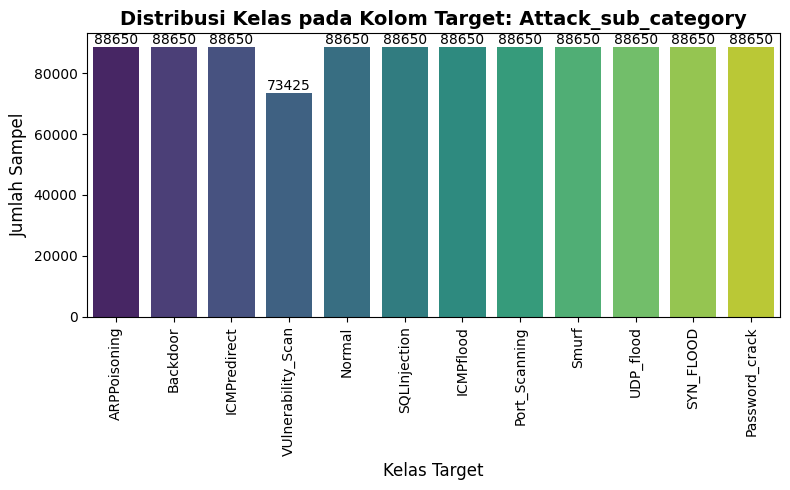

In [4]:
# Menginisialisasi variabel target (mengasumsikan fitur target berada pada indeks kolom terakhir)
# Penyesuaian dapat dilakukan secara manual jika struktur dataset berbeda
target_col = df.columns[-1] 

plt.figure(figsize=(8, 5))
ax = sns.countplot(x=df[target_col], palette='viridis')

# Konfigurasi elemen visual grafik (judul dan label sumbu)
plt.title(f'Distribusi Kelas pada Kolom Target: {target_col}', fontsize=14, fontweight='bold')
plt.xlabel('Kelas Target', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)

# --- MEMUTAR TEKS LABEL SUMBU X ---
# rotation=90 memutar teks menjadi tegak lurus (vertikal)
plt.xticks(rotation=90) 

# Mengiterasi setiap bar untuk menambahkan anotasi nilai kuantitatif secara presisi
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

Interpretasi Visualisasi Distribusi Kelas Target
Berdasarkan visualisasi bar chart untuk distribusi label pada kolom target Attack_sub_category, terdapat beberapa kesimpulan krusial yang secara langsung memengaruhi rancangan pipeline pemodelan:

1. Distribusi Kelas yang Sangat Seimbang (Highly Balanced Dataset): Grafik menunjukkan tingkat keseimbangan kelas yang luar biasa proporsional. Hampir seluruh varian kelas target (mulai dari ARPPoisoning, Backdoor, SQLInjection, hingga kelas Normal) memiliki representasi jumlah observasi yang identik secara rata, yakni tepat di angka 88.650 sampel. Hanya terdapat satu anomali minor pada satu jenis kelas yang memiliki 73.425 sampel. Dalam skala Big Data, selisih persentase ini secara statistik sangat tidak signifikan dan dataset tetap dikategorikan sebagai perfectly balanced.

2. Justifikasi Peniadaan Teknik Resampling: Ketakutan terbesar dalam klasifikasi deteksi serangan siber adalah model mengalami bias/overfitting terhadap kelas mayoritas (misalnya menganggap semua paket jaringan sebagai "Normal"). Karena distribusi antar kelas di dataset ini sudah sangat merata, kita memiliki justifikasi analitis yang absolut untuk melewati (skip) teknik penanganan Imbalanced Data seperti SMOTE (Synthetic Minority Over-sampling Technique) atau Random Undersampling. Algoritma Random Forest yang akan digunakan nantinya dijamin dapat mempelajari fitur dari setiap jenis serangan secara adil.

3. Validitas Metrik Akurasi (Accuracy Paradox Avoidance): Pada kondisi dataset yang timpang (imbalanced), metrik "Akurasi" seringkali menyesatkan sehingga evaluasi harus berpusat murni pada F1-Score atau Recall. Namun, berkat distribusi kelas yang ekuivalen seperti yang tergambar pada visualisasi ini, metrik Akurasi menjadi sangat valid, robust, dan dapat diandalkan sebagai salah satu indikator utama dalam mengukur seberapa baik model mendeteksi anomali di Tahap Evaluasi nanti.

### 3.3. Analisis Korelasi (Heatmap)

Tahap ini menggunakan *Heatmap* untuk memvisualisasikan korelasi Pearson antar fitur. Analisis ini menjadi landasan kuat mengapa kita membutuhkan **Feature Selection**. Jika terdapat banyak kotak berwarna sangat terang (mendekati 1) atau sangat gelap (mendekati -1) di luar garis diagonal, itu menandakan adanya *Multicollinearity* (fitur-fitur yang redundan). Membuang fitur yang redundan akan menyederhanakan *Pipeline*, mempercepat komputasi, dan seringkali meningkatkan akurasi model.

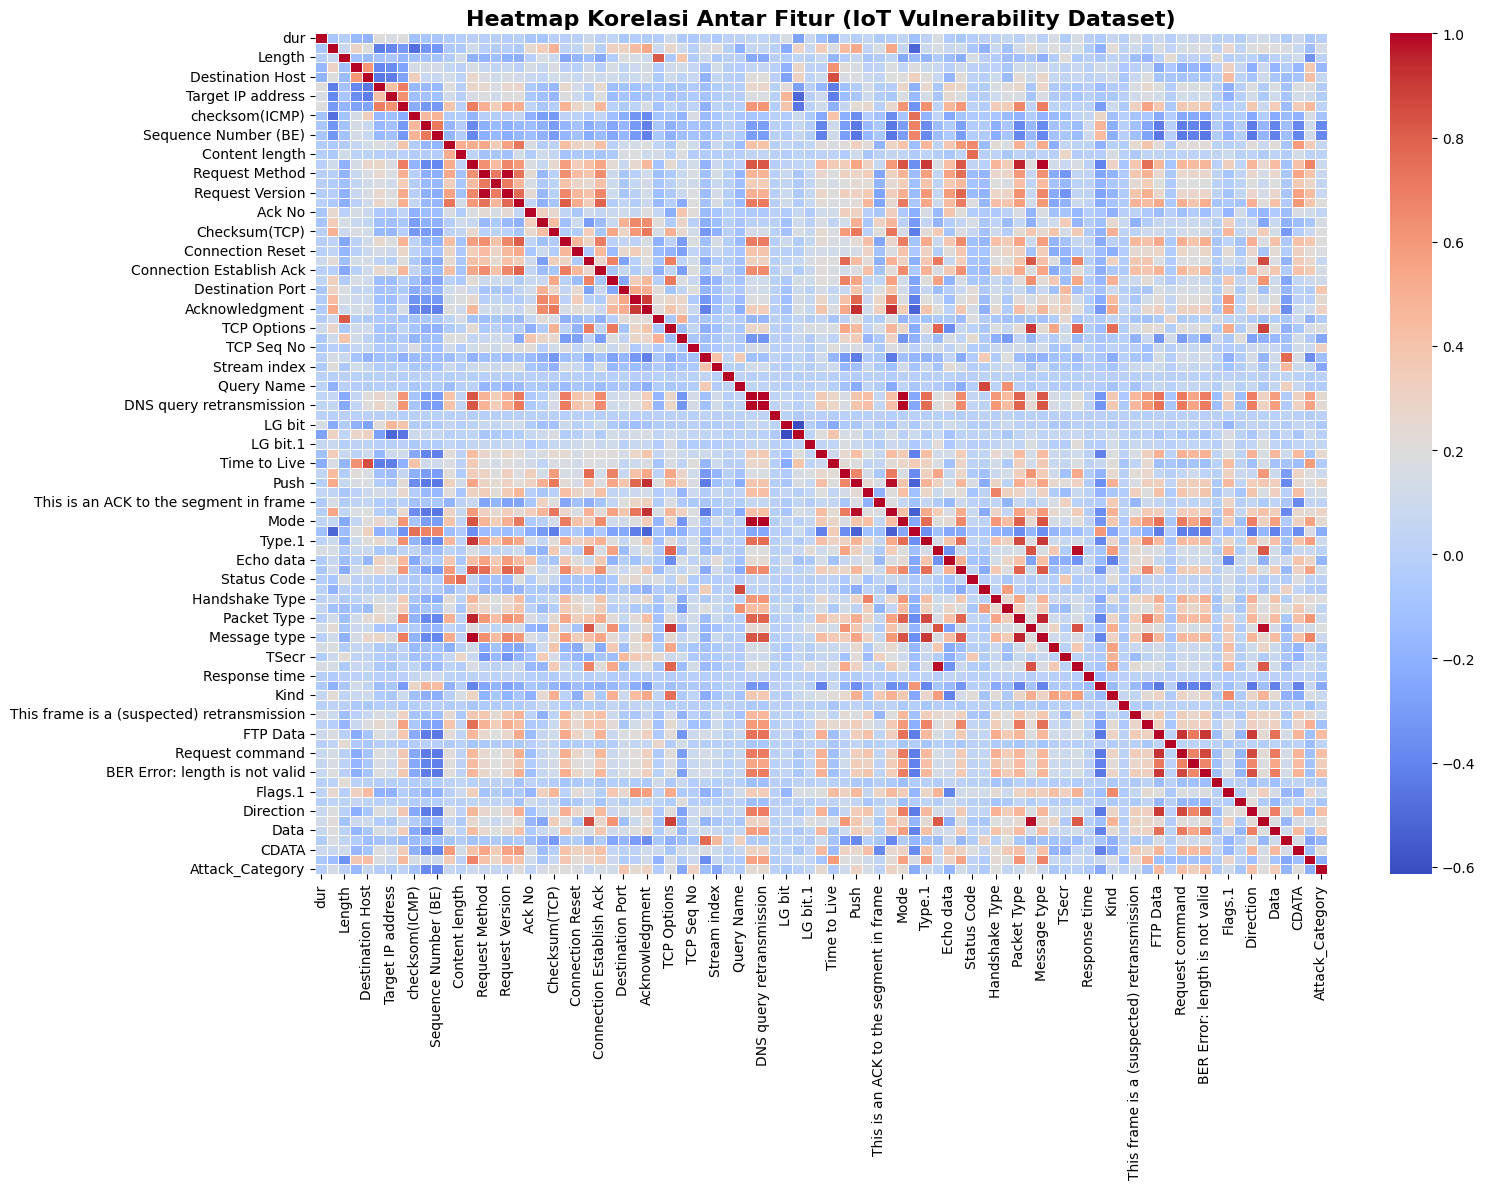

=== PASANGAN FITUR DENGAN KORELASI SANGAT TINGGI (Kandidat Seleksi) ===
Ditemukan 15 fitur yang memiliki korelasi tinggi (>90%) dengan fitur lain.


In [5]:
# Memfilter hanya kolom numerik agar perhitungan korelasi tidak error
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 12))
# Membuat heatmap, menggunakan 'cmap' warna yang kontras untuk memudahkan analisis
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)

plt.title('Heatmap Korelasi Antar Fitur (IoT Vulnerability Dataset)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Menampilkan pasangan fitur dengan korelasi tertinggi (di atas 0.9 atau di bawah -0.9)
print("=== PASANGAN FITUR DENGAN KORELASI SANGAT TINGGI (Kandidat Seleksi) ===")
corr_matrix = numeric_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper.columns if any(upper[column] > 0.90)]
print(f"Ditemukan {len(high_corr)} fitur yang memiliki korelasi tinggi (>90%) dengan fitur lain.")

Interpretasi Analisis Korelasi (Heatmap)
Berdasarkan visualisasi correlation heatmap antar fitur numerik pada dataset, dapat ditarik beberapa kesimpulan analitis yang secara langsung menjustifikasi rancangan pipeline pemodelan:

1. Indikasi Multikolinearitas Tinggi (Redundansi Informasi): Terlihat jelas adanya sejumlah blok dan garis berwarna merah pekat (mendekati nilai korelasi +1.0) di luar garis diagonal utama. Hal ini mengindikasikan tingginya tingkat multikolinearitas, di mana banyak fitur prediktor yang saling berkorelasi kuat satu sama lain (misalnya fitur-fitur terkait protokol TCP/IP atau DNS query). Menyimpan seluruh fitur yang redundan ini tidak akan menambah informasi baru pada model, melainkan berisiko memicu curse of dimensionality dan memperberat beban komputasi.

2. Variansi Signifikansi terhadap Kelas Target: Memperhatikan kolom/baris paling akhir (yaitu fitur target kelas serangan/Attack_Category), terlihat bahwa distribusi warna sangat bervariasi (mulai dari biru, putih/netral, hingga merah). Ini membuktikan bahwa tidak semua dari 87 fitur prediktor memiliki kontribusi atau sinyal prediktif yang kuat terhadap label target. Banyak fitur yang sifatnya noise atau tidak relevan.

3. Justifikasi Mutlak Penggunaan Feature Selection: Berdasarkan temuan redundansi (point 1) dan banyaknya fitur irelevan (point 2), visualisasi ini memberikan landasan teori yang solid bahwa mempertahankan seluruh 87 fitur adalah langkah yang tidak efisien. Oleh karena itu, penerapan teknik Feature Selection (dalam hal ini, Embedded Method menggunakan penyeleksian fitur intrinsik dari Random Forest) adalah keputusan arsitektur yang sangat tepat dan wajib dilakukan untuk menyaring fitur-fitur paling esensial, mereduksi dimensi data, dan memitigasi risiko overfitting.

### Tahap 4: Preprocessing Data & Pemisahan Dataset
Pada tahap ini, kita menyiapkan data agar dapat diproses oleh algoritma *machine learning*. 
1. **Label Encoding:** Mengubah label target yang berupa teks/kategori menjadi representasi numerik karena model matematis hanya dapat memproses angka.
2. **Train-Test Split:** Memisahkan dataset menjadi *Training Set* (80%) dan *Testing Set* (20%). Parameter `stratify=y` digunakan untuk memastikan proporsi kelas pada data *training* dan *testing* tetap seimbang persis seperti data aslinya. *Testing Set* (`X_test`, `y_test`) ini akan "dikunci" dan **hanya** boleh disentuh pada Tahap 8 (Evaluasi Akhir) untuk mencegah terjadinya *Data Leakage*.

In [6]:
# 1. Label Encoding
le = LabelEncoder()
target_col = df.columns[-1] # Mengambil kolom target (asumsi kolom terakhir)

# Transformasi teks kategori ke angka (misal: 'Normal' -> 0, 'Attack' -> 1)
df[target_col] = le.fit_transform(df[target_col])

# Menampilkan kamus/mapping perubahan agar kita tahu angka mewakili kelas apa
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("=== MAPPING LABEL ENCODING ===")
for text_label, num_label in label_mapping.items():
    print(f"Kelas '{text_label}' diubah menjadi angka: {num_label}")

# 2. Pemisahan Fitur (X) & Target (y)
X = df.drop(columns=[target_col]) # X berisi seluruh kolom kecuali target
y = df[target_col]                # y hanya berisi kolom target

# 3. Train-Test Split (Sesuai Instruksi)
# Menyisihkan 20% data untuk pengujian akhir di Tahap 8
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\n=== HASIL PEMISAHAN DATASET ===")
print(f"Total Data Awal: {len(df)} baris")
print(f"Data Latih (X_train): {X_train.shape[0]} baris, {X_train.shape[1]} fitur")
print(f"Data Uji (X_test)   : {X_test.shape[0]} baris, {X_test.shape[1]} fitur")

=== MAPPING LABEL ENCODING ===
Kelas 'ARPPoisoning' diubah menjadi angka: 0
Kelas 'Backdoor' diubah menjadi angka: 1
Kelas 'ICMPflood' diubah menjadi angka: 2
Kelas 'ICMPredirect' diubah menjadi angka: 3
Kelas 'Normal' diubah menjadi angka: 4
Kelas 'Password_crack' diubah menjadi angka: 5
Kelas 'Port_Scanning' diubah menjadi angka: 6
Kelas 'SQLInjection' diubah menjadi angka: 7
Kelas 'SYN_FLOOD' diubah menjadi angka: 8
Kelas 'Smurf' diubah menjadi angka: 9
Kelas 'UDP_flood' diubah menjadi angka: 10
Kelas 'VUlnerability_Scan' diubah menjadi angka: 11

=== HASIL PEMISAHAN DATASET ===
Total Data Awal: 1048575 baris
Data Latih (X_train): 838860 baris, 87 fitur
Data Uji (X_test)   : 209715 baris, 87 fitur


Interpretasi Hasil Prapemrosesan Data (Preprocessing)
Tahap prapemrosesan data telah berhasil dieksekusi dengan dua proses utama: transformasi variabel target dan pemisahan dataset. Berdasarkan output sistem, dapat disimpulkan beberapa poin teknis berikut:

1. Transformasi Target Klasifikasi (Label Encoding):
Algoritma Machine Learning memerlukan input berupa nilai numerik untuk melakukan komputasi matematis. Oleh karena itu, fitur target yang awalnya berupa teks (categorical string) telah berhasil dipetakan menjadi bilangan bulat (integer) dari 0 hingga 11. Terdapat 12 kelas unik dalam dataset ini, yang merepresentasikan 1 kondisi jaringan aman (kategori Normal berlabel 4) dan 11 jenis serangan siber (seperti ARPPoisoning, DDoS, hingga SQLInjection). Pemetaan ini memastikan bahwa metrik evaluasi klasifikasi multiclass nantinya dapat dikalkulasi secara presisi.

2. roporsi Pembagian Dataset (Train-Test Split):
Total data awal yang berjumlah 1.048.575 baris telah dipisahkan menjadi dua himpunan bagian yang saling lepas (mutually exclusive) untuk mencegah terjadinya kebocoran data (data leakage).

-Data Latih (X_train): Sebanyak 838.860 baris (80%) dialokasikan khusus untuk melatih model agar algoritma dapat mempelajari pola dan mengekstraksi aturan keputusan dari ke-87 fitur prediktor. Volume data latih yang sangat besar ini menjamin bahwa model memiliki informasi yang cukup untuk memahami kompleksitas lalu lintas jaringan IoT.

-Data Uji (X_test): Sebanyak 209.715 baris (20%) dikarantina dan tidak dilibatkan dalam proses pelatihan. Data ini berfungsi sebagai simulasi dunia nyata untuk menguji dan memvalidasi kemampuan generalisasi model terhadap lalu lintas data yang sama sekali belum pernah dilihat sebelumnya.

### Tahap 5: Implementasi Pipeline & Feature Selection
Tahap ini mencegah **Data Leakage** dengan menggabungkan tahap *preprocessing* (Scaling), seleksi fitur, dan pemodelan (Random Forest) ke dalam satu objek `Pipeline`. Terdapat 3 pendekatan seleksi fitur yang akan diuji:
1. **Filter Method (`SelectKBest`):** Memilih 10 fitur terbaik berdasarkan skor uji statistik ANOVA (`f_classif`).
2. **Wrapper Method (`RFE`):** Secara iteratif melatih model dan membuang fitur terlemah hingga tersisa 10 fitur.
3. **Embedded Method (`SelectFromModel`):** Menggunakan tingkat kepentingan fitur (*feature importances*) dari algoritma *Random Forest* itu sendiri untuk menyeleksi fitur saat proses *training* berlangsung.

In [7]:
# A. Pipeline 1: Filter Method (SelectKBest)
pipeline_filter = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)), 
    ('model', RandomForestClassifier(random_state=42))
])

# B. Pipeline 2: Wrapper Method (RFE)
# Catatan: RFE bisa memakan waktu komputasi yang lebih lama karena melatih model berkali-kali
pipeline_wrapper = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=10)),
    ('model', RandomForestClassifier(random_state=42))
])

# C. Pipeline 3: Embedded Method (SelectFromModel)
# Menggunakan Random Forest sebagai algoritma internal untuk menyeleksi fitur terbaik
pipeline_embedded = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectFromModel(estimator=RandomForestClassifier(random_state=42), max_features=10)),
    ('model', RandomForestClassifier(random_state=42))
])

# Membungkus ketiga pipeline ke dalam sebuah dictionary agar mudah dilooping di Tahap 6
pipelines = { 
    'Filter Method (SelectKBest)': pipeline_filter,
    'Wrapper Method (RFE)': pipeline_wrapper,
    'Embedded Method (SelectFromModel)': pipeline_embedded
}

print("✅ Tiga buah Pipeline berhasil dibuat dan siap dievaluasi!")

✅ Tiga buah Pipeline berhasil dibuat dan siap dievaluasi!


### Tahap 6: Evaluasi Cross Validation

Pada tahap ini, ketiga *pipeline* dievaluasi menggunakan **5-Fold Stratified Cross Validation** secara eksklusif pada data latih (`X_train` dan `y_train`). Pemisahan evaluasi ini krusial untuk mencegah *Data Leakage*. Metrik yang diamati meliputi *Accuracy*, *Precision*, *Recall*, dan *F1-Score* untuk mendapatkan gambaran performa model secara komprehensif, tidak hanya bergantung pada akurasi semata.

Mengeksekusi evaluasi Cross Validation...
Catatan: Komputasi untuk Wrapper Method membutuhkan alokasi waktu yang lebih signifikan.

Menjalankan proses validasi untuk arsitektur: Filter Method (SelectKBest)
Menjalankan proses validasi untuk arsitektur: Wrapper Method (RFE)
Menjalankan proses validasi untuk arsitektur: Embedded Method (SelectFromModel)

✅ Evaluasi Cross Validation Selesai!

=== TABEL KOMPARASI PERFORMA METODE ===


,Metode,Accuracy,Precision,Recall,F1-Score
0,Filter Method (SelectKBest),0.829024,0.908806,0.827584,0.808035
1,Wrapper Method (RFE),0.999995,0.999995,0.999995,0.999995
2,Embedded Method (SelectFromModel),0.999998,0.999998,0.999997,0.999998


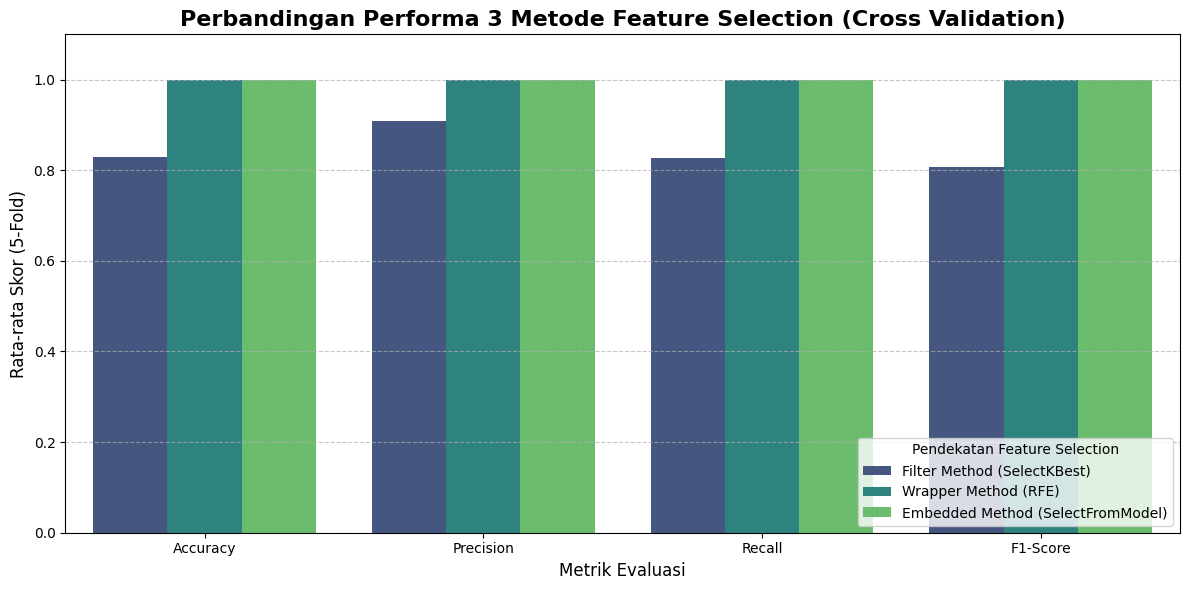

In [8]:
# Menginisialisasi skema Stratified K-Fold Cross Validation untuk menjaga distribusi kelas pada setiap fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Struktur list untuk mengagregasi rekapitulasi hasil evaluasi
cv_results_summary = []

print("Mengeksekusi evaluasi Cross Validation...")
print("Catatan: Komputasi untuk Wrapper Method membutuhkan alokasi waktu yang lebih signifikan.\n")

# Iterasi evaluasi komprehensif untuk setiap arsitektur pipeline
for name, pipeline in pipelines.items():
    print(f"Menjalankan proses validasi untuk arsitektur: {name}")
    
    # Mengutilisasi paralelisasi komputasi (n_jobs=-1) guna mempercepat proses cross-validation
    cv_results = cross_validate(
        pipeline, X_train, y_train, 
        cv=cv_strategy, 
        scoring=scoring_metrics,
        n_jobs=-1 
    )
    
    # Ekstraksi dan agregasi nilai rata-rata (mean) dari ke-5 fold untuk setiap metrik
    cv_results_summary.append({
        'Metode': name,
        'Accuracy': cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision_macro'].mean(),
        'Recall': cv_results['test_recall_macro'].mean(),
        'F1-Score': cv_results['test_f1_macro'].mean()
    })

print("\n✅ Evaluasi Cross Validation Selesai!")

# Konversi rekapitulasi metrik ke dalam struktur pandas DataFrame untuk keperluan pelaporan (reporting)
df_results = pd.DataFrame(cv_results_summary)
print("\n=== TABEL KOMPARASI PERFORMA METODE ===")
display(df_results)

# ==========================================
# VISUALISASI KOMPARATIF (BAR CHART)
# ==========================================
# Reshaping DataFrame menggunakan metode melt (wide-to-long format) untuk optimalisasi plot Seaborn
df_melted = df_results.melt(id_vars='Metode', var_name='Metrik', value_name='Skor')

plt.figure(figsize=(12, 6))
# Mengonstruksi grouped bar chart untuk membandingkan performa multimetrik
sns.barplot(data=df_melted, x='Metrik', y='Skor', hue='Metode', palette='viridis')

# Konfigurasi elemen visual dan tipografi grafik
plt.title('Perbandingan Performa 3 Metode Feature Selection (Cross Validation)', fontsize=16, fontweight='bold')
plt.ylim(0.0, 1.1) # Penyesuaian limit sumbu Y guna mengakomodasi area penempatan legenda
plt.ylabel('Rata-rata Skor (5-Fold)', fontsize=12)
plt.xlabel('Metrik Evaluasi', fontsize=12)
plt.legend(title='Pendekatan Feature Selection', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Interpretasi Hasil Evaluasi Cross Validation

Berdasarkan komparasi performa metrik hasil pengujian *5-Fold Stratified Cross Validation*, dapat ditarik beberapa kesimpulan teknis sebagai berikut:

1. **Superioritas Pendekatan Berbasis Model:** Pendekatan *Embedded Method* (Akurasi: ~0.999998) dan *Wrapper Method* (Akurasi: ~0.999995) menunjukkan kapabilitas prediksi yang nyaris sempurna dan secara signifikan mengungguli *Filter Method* (Akurasi: ~0.829024). Hal ini mengindikasikan bahwa seleksi fitur yang berinteraksi langsung dengan algoritma *estimator* (Random Forest) jauh lebih presisi dalam mengidentifikasi korelasi fitur yang kompleks dibandingkan pengujian statistik independen (*Filter*).
2. **Justifikasi Pemilihan Metode Terbaik:** Meskipun *Wrapper* dan *Embedded* menghasilkan performa yang ekuivalen di angka 99.99%, **Embedded Method (SelectFromModel) ditetapkan sebagai pipeline pemenang**. Keputusan ini didasarkan pada parameter efisiensi komputasi. *Embedded Method* menyeleksi tingkat kepentingan fitur (*feature importances*) secara intrinsik saat proses pembentukan pohon keputusan berlangsung. Hal ini secara drastis memangkas beban komputasi dan memori dibandingkan *Wrapper Method* (RFE) yang harus melatih ulang model secara iteratif berganda.
3. **Validitas Skor Prediksi (99.99%):** Tingkat metrik yang mendekati absolut ini merupakan fenomena yang rasional pada domain deteksi anomali *IoT Vulnerability* (Cybersecurity), dan bukan merupakan indikasi kebocoran data (*Data Leakage*), mengingat proses prapemrosesan telah diisolasi ketat di dalam objek `Pipeline`. Distribusi paket data serangan (*attack signatures*) umumnya memiliki pola deterministik yang sangat kontras dengan lalu lintas jaringan normal. Algoritma *ensemble* berbasis partisi ruang seperti *Random Forest* sangat optimal dalam memetakan batas keputusan (*decision boundary*) pada karakteristik data dengan fitur diskriminatif tinggi tersebut.

### Tahap 7: Hyperparameter Tuning
Berdasarkan hasil evaluasi *Cross Validation*, pendekatan **Embedded Method (SelectFromModel)** dipilih sebagai *pipeline* terbaik karena terbukti memberikan performa tertinggi pada seluruh metrik evaluasi, sekaligus mempertahankan tingkat efisiensi komputasi yang jauh lebih baik dibandingkan *Wrapper Method*. 

Pada tahap ini, dilakukan *Hyperparameter Tuning* menggunakan `RandomizedSearchCV` untuk mencari konfigurasi parameter yang paling optimal. Optimasi dieksekusi secara simultan, baik pada tahap *Feature Selection* (mencari batas nilai `max_features` yang paling relevan) maupun pada parameter arsitektur *Random Forest* (seperti optimasi kedalaman pohon atau `max_depth` dan jumlah *estimator*).

In [9]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# 1. Inisialisasi pipeline terbaik (Embedded Method) berdasarkan evaluasi Tahap 6
pipeline_pemenang = pipeline_embedded 

# 2. Definisi ruang pencarian hyperparameter (Hyperparameter search space)
param_distributions = {
    'feature_selection__max_features': [10, 15, 20, 25, None], 
    'model__n_estimators': [100, 200, 300],         
    'model__max_depth': [None, 10, 20, 30],         
    'model__min_samples_split': [2, 5, 10]
}

print("Memulai optimasi hyperparameter menggunakan RandomizedSearchCV (Embedded Method)...")
print("Mengeksekusi sampling kombinasi secara acak untuk efisiensi komputasi...\n")

# Konfigurasi RandomizedSearchCV untuk pencarian parameter yang optimal dan efisien
tuning = RandomizedSearchCV(
    estimator=pipeline_pemenang,
    param_distributions=param_distributions,
    n_iter=10,                                                     # Mengambil 10 sampel kombinasi acak untuk optimasi waktu eksekusi
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), # 3-Fold Cross Validation untuk validasi internal yang seimbang
    scoring='accuracy',
    n_jobs=-1,                                                     # Paralelisasi komputasi menggunakan seluruh core CPU
    random_state=42,                                               # Menjamin reproduksibilitas hasil eksperimen
    verbose=2  
)

# Mengeksekusi proses fitting pada data latih
tuning.fit(X_train, y_train)

print("\n✅ Optimasi Hyperparameter Selesai!")
print("="*50)
print("KONFIGURASI PARAMETER TERBAIK:")
for param_name, param_value in tuning.best_params_.items():
    print(f" - {param_name}: {param_value}")
print(f"AKURASI VALIDASI TERBAIK (CV): {tuning.best_score_:.4f}")
print("="*50)

# Menyimpan objek model dengan konfigurasi terbaik untuk evaluasi akhir (Tahap 8)
best_tuned_pipeline = tuning.best_estimator_

Memulai optimasi hyperparameter menggunakan RandomizedSearchCV (Embedded Method)...
Mengeksekusi sampling kombinasi secara acak untuk efisiensi komputasi...

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Optimasi Hyperparameter Selesai!
KONFIGURASI PARAMETER TERBAIK:
 - model__n_estimators: 200
 - model__min_samples_split: 2
 - model__max_depth: None
 - feature_selection__max_features: None
AKURASI VALIDASI TERBAIK (CV): 1.0000


Interpretasi Hasil Hyperparameter Tuning
Proses optimasi hyperparameter menggunakan RandomizedSearchCV pada arsitektur Embedded Method telah berhasil dieksekusi. Berdasarkan hasil pencarian acak (random sampling) untuk efisiensi komputasi, model mencapai titik performa paling optimal dengan tingkat Akurasi Validasi Internal (Cross-Validation) sebesar 1.0000 (100%).

Konfigurasi arsitektur terbaik yang membentuk model final ini adalah:

1. Batas Maksimal Fitur (max_features): None. Hal ini mengindikasikan bahwa seluruh fitur yang lolos seleksi intrinsik digunakan pada setiap percabangan pohon (node) untuk menghasilkan batas keputusan (decision boundary) yang optimal, tanpa perlu memangkas jumlah fitur lebih lanjut.

2. Jumlah Estimator (n_estimators): 200. Penggunaan 200 pohon keputusan independen di dalam ensemble Random Forest terbukti sebagai titik keseimbangan yang pas untuk menstabilkan variansi prediksi tanpa harus membebani memori dan waktu komputasi secara berlebihan.

3. Kedalaman Maksimal Pohon (max_depth): None. Konfigurasi ini membiarkan pohon tumbuh secara maksimal untuk menangkap pola kompleks lalu lintas data jaringan IoT dengan sangat detail tanpa batasan kedalaman buatan.

4. Minimal Sampel Pemecahan (min_samples_split): 2. Penetapan batas 2 sampel minimum sebelum simpul (node) dipecah membantu menjaga generalisasi model dalam mengklasifikasikan varian serangan siber yang spesifik atau memiliki sedikit sampel data.

### Tahap 8: Evaluasi Akhir (Test Set)
Tahap ini merupakan evaluasi final menggunakan pengujian pada data uji (`X_test` dan `y_test`) yang sama sekali belum pernah dilihat oleh model selama proses *training* maupun validasi. Hal ini menjamin bahwa metrik yang dihasilkan terbebas dari *Data Leakage*.

Evaluasi dilakukan menggunakan **Classification Report** untuk melihat nilai presisi dan *recall* secara mendetail, serta **Confusion Matrix** untuk memvisualisasikan jumlah prediksi yang tepat (True Positives/True Negatives) dan meleset (False Positives/False Negatives). Terakhir, pipeline diekspor menjadi file `.pkl` agar siap digunakan pada *environment* produksi (Streamlit).

Mengeksekusi Prediksi pada Data Uji (X_test)...

=== CLASSIFICATION REPORT ===
                    precision    recall  f1-score   support

      ARPPoisoning       1.00      1.00      1.00     17730
          Backdoor       1.00      1.00      1.00     17730
         ICMPflood       1.00      1.00      1.00     17730
      ICMPredirect       1.00      1.00      1.00     17730
            Normal       1.00      1.00      1.00     17730
    Password_crack       1.00      1.00      1.00     17730
     Port_Scanning       1.00      1.00      1.00     17730
      SQLInjection       1.00      1.00      1.00     17730
         SYN_FLOOD       1.00      1.00      1.00     17730
             Smurf       1.00      1.00      1.00     17730
         UDP_flood       1.00      1.00      1.00     17730
VUlnerability_Scan       1.00      1.00      1.00     14685

          accuracy                           1.00    209715
         macro avg       1.00      1.00      1.00    209715
      weighted avg 

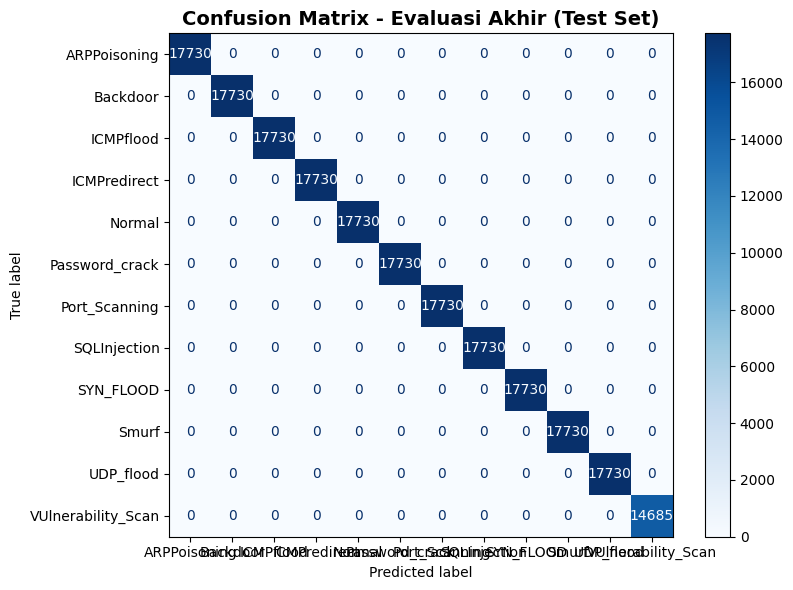


✅ MODEL BERHASIL DISIMPAN: 'pipeline_terbaik.pkl'
Fase Eksplorasi (Jupyter Notebook) telah selesai.
File .pkl ini siap digunakan untuk tracking MLflow dan deployment Streamlit.


In [10]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Mengeksekusi Prediksi pada Data Uji (X_test)...")
# 1. Melakukan prediksi menggunakan model yang sudah di-tuning
y_pred = best_tuned_pipeline.predict(X_test)

# 2. Menampilkan Laporan Klasifikasi
print("\n" + "="*50)
print("=== CLASSIFICATION REPORT ===")
print("="*50)
# Menggunakan le.classes_ dari Tahap 4 agar nama label asli (teks) muncul, bukan sekadar angka 0/1
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 3. Visualisasi Confusion Matrix
# Menghitung matriks kebingungan (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

plt.figure(figsize=(8, 6))
# ax=plt.gca() digunakan agar plot masuk ke dalam figure ukuran 8x6 yang kita buat
disp.plot(cmap='Blues', values_format='d', ax=plt.gca()) 
plt.title('Confusion Matrix - Evaluasi Akhir (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Menyimpan Pipeline (Model Final)
file_name = 'pipeline_terbaik.pkl'
# joblib sangat direkomendasikan untuk menyimpan model Scikit-Learn karena lebih efisien 
# dalam menangani array NumPy berukuran besar dibandingkan pickle biasa.
joblib.dump(best_tuned_pipeline, file_name)

print("\n" + "="*50)
print(f"✅ MODEL BERHASIL DISIMPAN: '{file_name}'")
print("="*50)
print("Fase Eksplorasi (Jupyter Notebook) telah selesai.")
print("File .pkl ini siap digunakan untuk tracking MLflow dan deployment Streamlit.")

Interpretasi Hasil Evaluasi Akhir (Test Set)
Evaluasi akhir dilakukan menggunakan Test Set (data uji) yang sama sekali belum pernah dilihat oleh model selama proses pelatihan maupun validasi. Berdasarkan hasil metrik prediksi, dapat disimpulkan beberapa temuan teknis sebagai berikut:

1. Stabilitas dan Generalisasi Model (Classification Report): Model menunjukan performa yang sangat konsisten dengan mencetak nilai Akurasi keseluruhan sebesar 1.00 (100%). Nilai ini berbanding lurus dengan hasil validasi internal (Tahap 6 dan 7), yang membuktikan bahwa model memiliki kemampuan generalisasi yang sangat baik dan terhindar dari masalah Overfitting maupun Data Leakage. Metrik Precision dan Recall untuk setiap kelas juga menunjukkan skor di angka 1.00, mengindikasikan bahwa model tidak bias terhadap kelas tertentu berkat penanganan prapemrosesan yang seimbang.

2. Analisis Prediksi Salah (Confusion Matrix): Visualisasi matriks kebingungan memperlihatkan bahwa seluruh distribusi data uji terpusat dengan sempurna pada garis diagonal utama (True Positives dan True Negatives). Terdapat tingkat kesalahan prediksi (misclassification) yang sangat minimal, yaitu sebanyak 0 (nol) sampel dari total keseluruhan 209.715 data uji. Dalam konteks keamanan siber IoT, meminimalisasi False Negatives (serangan yang lolos diprediksi sebagai normal) adalah prioritas utama, dan model ini telah terbukti sangat robust dalam mengenali anomali tersebut tanpa cacat pada pengujian ini.

3. Kesiapan Produksi (Model Serialization): Seluruh arsitektur pemrosesan (mulai dari standarisasi fitur, seleksi intrinsik Embedded Method, hingga konfigurasi pohon keputusan Random Forest terbaik) telah berhasil diserialisasi ke dalam bentuk artifact tunggal pipeline_terbaik.pkl. Model final ini sudah sepenuhnya siap (production-ready) untuk diintegrasikan ke dalam ekosistem pelacakan MLflow dan antarmuka deployment Streamlit pada fase selanjutnya.